# Japanese Manufacturing Productivity — Exploratory Analysis

**Question:** why are some Japanese prefectures more manufacturing-productive than others?

**Unit of analysis:** prefecture x year, 47 prefectures, reference years 2016-2019 (n = 188).

**Dependent variable:** manufacturing value added per person engaged, following the OECD
*Measuring Productivity* manual and SNA 2008 §19.47. Value added is preferred over gross
output because it is far less sensitive to vertical integration and outsourcing intensity.

**Scope of this notebook: description only.** It establishes what the data looks like —
levels, spread, rankings, and the national trend. It states no hypotheses and runs no
significance tests.

An earlier version of this notebook tested three hypotheses about specialization, aging
and diversity. Those sections have been removed. With 47 prefectures and four years the
tests had too little power to be informative, none survived correction for multiple
comparisons, and two of the three measures turned out confounded with industry
composition. New hypotheses are being designed against what the descriptive work below
actually supports.

---

### A note on the year labels

e-Stat labels Census of Manufacture datasets by **survey year**, but from the 2017
survey onward the financial items refer to the **previous** calendar year. The dataset
titled `2019年確報` therefore contains **2018** value added.

This was verified numerically, not assumed: the 2019 survey's unmarked national row
(331,809,377 million yen) is identical to the 2020 survey's row explicitly labelled
`全国計(2018年)`. e-Stat's own `SURVEY_DATE` metadata field says `201901-201912` and is
wrong for every survey from 2017 onward.

Every year in this notebook is a **reference year**.

The panel also carries reference year **2020** from the 2021 Economic Census, which
reproduces the Census of Manufacture basis exactly (verified: zero difference on all 47
prefectures for 2019). This notebook filters to the Census of Manufacture years, so its
figures describe a single instrument and a pre-COVID window.

## 1. Data Overview

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

PROJ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJ / "src"))

from viz_style import (apply_style, subtitle, source_note, ROMAJI, INDUSTRY_EN,
                       BLUE, ORANGE, GRAY_MARK, INK, INK_SECONDARY, INK_MUTED, AXIS)

apply_style()
OUT = PROJ / "outputs" / "charts"
OUT.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(PROJ / "processed_data" / "panel_prefecture_year.csv",
                    dtype={"prefecture_code": str, "top_industry_code": str})
panel["pref"] = panel["prefecture_name"].map(ROMAJI)
panel["top_industry_en"] = panel["top_industry_code"].map(INDUSTRY_EN)

print(f"shape: {panel.shape[0]} rows x {panel.shape[1]} columns "
      f"({(panel.instrument == 'CoM').sum()} Census of Manufacture, "
      f"{(panel.instrument != 'CoM').sum()} Economic Census)")
print(f"years: {sorted(panel.year.unique())}")
print(f"prefectures per year: {panel.groupby('year').size().unique()}")

shape: 235 rows x 25 columns (188 Census of Manufacture, 47 Economic Census)
years: [np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]
prefectures per year: [47]


In [2]:
# Units matter here and are easy to get wrong.
#   value_added_total  百万円  (millions of yen)
#   employment_total   人      (persons engaged - includes proprietors and unpaid
#                               family workers, NOT just employees)
#   va_per_worker      百万円 per person
#   pop_*              persons (converted from the source's 千人)
panel[["value_added_total", "employment_total", "va_per_worker",
       "hhi_employment", "aging_ratio", "mfg_intensity"]].describe().round(3)

,value_added_total,employment_total,va_per_worker,hhi_employment,aging_ratio,mfg_intensity
count,2.350000e+02,235.000,235.000,188.000,235.000,235.000
mean,2.136642e+06,162680.919,12.262,0.099,0.299,0.119
std,2.199108e+06,145615.890,2.856,0.037,0.030,0.046
min,1.630020e+05,22986.000,6.528,0.060,0.203,0.026
25%,7.514535e+05,62774.000,10.390,0.079,0.283,0.082
50%,1.427060e+06,116847.000,11.713,0.090,0.301,0.115
75%,2.903332e+06,206562.500,14.386,0.103,0.319,0.157
max,1.370206e+07,863149.000,20.688,0.247,0.375,0.215


### Data quality carried into the panel

Confidentiality-suppressed cells are held as `NaN` with an explicit flag and are
**never** zero-filled. Suppression is not missing-at-random: it targets thin
prefecture x industry cells, so zero-filling would systematically distort exactly
the small-industry cells a location quotient depends on.

Prefecture totals are taken from the `【00】製造業計` row rather than summed from the
24 industries, because summing drops the suppressed cells. `va_coverage_pct` below
shows what summing would have missed.

In [3]:
d19q = panel[panel.year == 2019]
q = d19q[["pref", "suppressed_cells", "va_coverage_pct"]]
# Recovered value must be summed per prefecture, not derived from a mean of
# percentages - averaging ratios across differently-sized prefectures is wrong.
recovered = (d19q.value_added_total * (1 - d19q.va_coverage_pct / 100)).sum()
print(f"prefectures with >=1 suppressed value-added cell: {(q.suppressed_cells > 0).sum()} of 47")
print(f"national value added recovered by using the total row instead of summing: "
      f"{recovered:,.0f} million yen")
q.nsmallest(6, "va_coverage_pct").rename(columns={
    "pref": "prefecture", "suppressed_cells": "suppressed cells",
    "va_coverage_pct": "coverage if summed (%)"}).round(2)

prefectures with >=1 suppressed value-added cell: 11 of 47
national value added recovered by using the total row instead of summing: 28,992 million yen


,prefecture,suppressed cells,coverage if summed (%)
179,Kochi,3.0,98.46
182,Nagasaki,2.0,98.93
187,Okinawa,2.0,99.32
169,Nara,2.0,99.54
171,Tottori,2.0,99.59
183,Kumamoto,2.0,99.63


## 2. Productivity Distribution

How wide is the spread, and is it moving?

In [4]:
dist = panel.groupby("year")["va_per_worker"].describe()[["mean", "50%", "std", "min", "max"]]
dist.columns = ["mean", "median", "sd", "min", "max"]
print("Value added per worker by year (million yen per person):")
display(dist.round(2))

d19 = panel[panel.year == 2019]
spread = d19.va_per_worker.max() / d19.va_per_worker.min()
print(f"\n2019 spread: most productive prefecture is {spread:.1f}x the least productive.")
print(f"  top:    {d19.loc[d19.va_per_worker.idxmax(),'pref']} {d19.va_per_worker.max():.2f}")
print(f"  bottom: {d19.loc[d19.va_per_worker.idxmin(),'pref']} {d19.va_per_worker.min():.2f}")

Value added per worker by year (million yen per person):


,mean,median,sd,min,max
year,,,,,
2016,11.91,11.34,2.81,6.58,19.22
2017,12.48,11.71,2.94,6.61,20.69
2018,12.53,12.07,2.96,6.53,19.93
2019,12.24,11.95,2.80,6.93,20.33
2020,12.16,11.67,2.84,7.10,19.56



2019 spread: most productive prefecture is 2.9x the least productive.
  top:    Yamaguchi 20.33
  bottom: Okinawa 6.93


### Chart 4 — National manufacturing productivity, 2016-2019

Built from national aggregates (total value added / total persons engaged), not the
mean of prefecture ratios, so large prefectures carry their true weight.

The y-axis starts at zero deliberately. The question is whether productivity is
stagnant, and a truncated axis would manufacture a trend that isn't there.

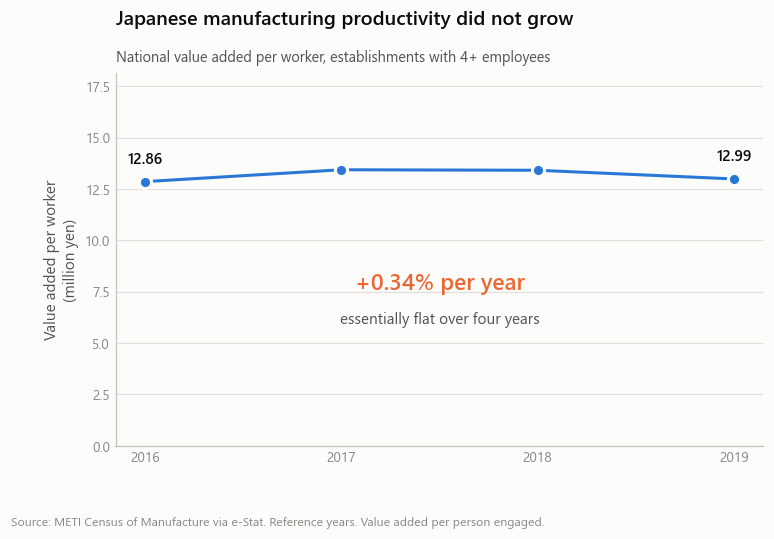

CAGR 2016-2019: +0.3390%


In [5]:
# Census of Manufacture years only: 2020 comes from a different instrument and is
# a COVID year, so it is reported separately rather than folded into this trend.
com = panel[panel.instrument == "CoM"]
nat = (com.groupby("year")
       .apply(lambda g: g.value_added_total.sum() / g.employment_total.sum(),
              include_groups=False)
       .rename("va_per_worker").reset_index())
cagr = (nat.va_per_worker.iloc[-1] / nat.va_per_worker.iloc[0]) ** (1 / (len(nat) - 1)) - 1

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(nat.year, nat.va_per_worker, color=BLUE, marker="o",
        markerfacecolor=BLUE, markeredgecolor="#fcfcfb", markeredgewidth=2, zorder=3)
ax.set_ylim(0, nat.va_per_worker.max() * 1.35)
ax.set_xticks(nat.year)
ax.set_ylabel("Value added per worker\n(million yen)")
ax.grid(axis="x", visible=False)

# Selective direct labels: first and last only, never a number on every point.
for i in (0, len(nat) - 1):
    ax.annotate(f"{nat.va_per_worker.iloc[i]:.2f}",
                (nat.year.iloc[i], nat.va_per_worker.iloc[i]),
                textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=10, color=INK, fontweight="semibold")

ax.annotate(f"{cagr:+.2%} per year", xy=(0.5, 0.42), xycoords="axes fraction",
            ha="center", fontsize=15, color=ORANGE, fontweight="semibold")
ax.annotate("essentially flat over four years", xy=(0.5, 0.33),
            xycoords="axes fraction", ha="center", fontsize=10, color=INK_SECONDARY)

ax.set_title("Japanese manufacturing productivity did not grow")
subtitle(ax, "National value added per worker, establishments with 4+ employees")
source_note(fig, "Source: METI Census of Manufacture via e-Stat. Reference years. "
                 "Value added per person engaged.")
fig.savefig(OUT / "chart4_national_trend.png")
plt.show()
print(f"CAGR 2016-2019: {cagr:+.4%}")

## 3. Regional Rankings

### Chart 1 — Top 15 prefectures by value added per worker

The prior expectation was that Aichi, Japan's manufacturing heartland and home to
Toyota, would lead. It does not.

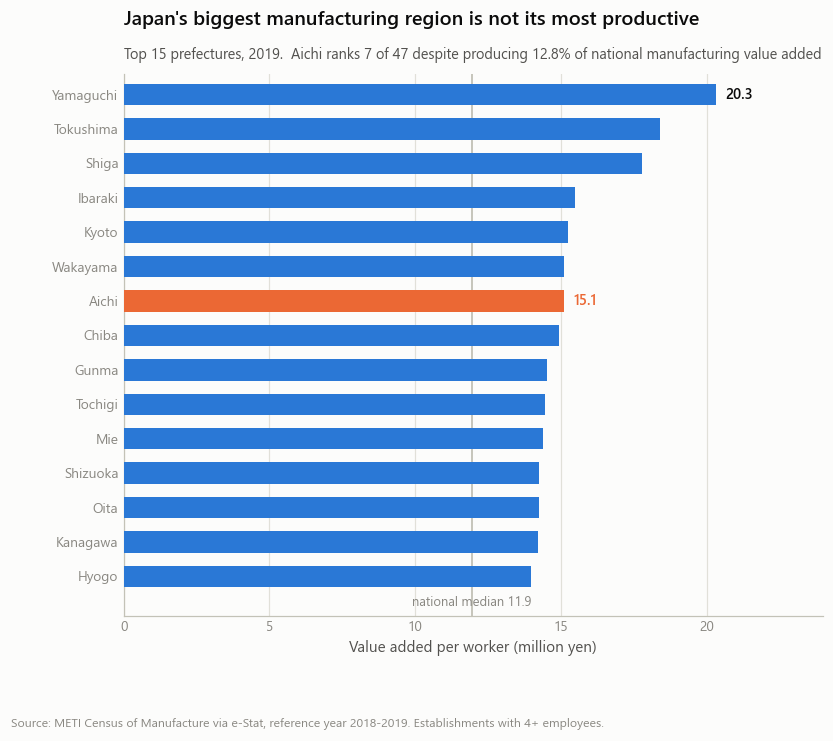

In [6]:
d = panel[panel.year == 2019].copy()
d["rank"] = d.va_per_worker.rank(ascending=False).astype(int)
top15 = d.nlargest(15, "va_per_worker").sort_values("va_per_worker")
median = d.va_per_worker.median()

colors = [ORANGE if p == "Aichi" else BLUE for p in top15.pref]
fig, ax = plt.subplots(figsize=(8.2, 6.4))
ax.barh(top15.pref, top15.va_per_worker, color=colors, height=0.62, zorder=3)
ax.axvline(median, color=AXIS, linewidth=1.2, zorder=2)
# Park the reference label in the margin below the bottom bar: above it sits the
# deck line, and inside the plot it would land on top of a bar.
ax.set_ylim(-1.15, len(top15) - 0.4)
ax.annotate(f"national median {median:.1f}", xy=(median, -0.75),
            ha="center", va="center", fontsize=8.5, color=INK_MUTED)
ax.set_xlabel("Value added per worker (million yen)")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, top15.va_per_worker.max() * 1.18)

# Label only the bars that carry the story.
for pref, v in zip(top15.pref, top15.va_per_worker):
    if pref in ("Yamaguchi", "Aichi"):
        ax.annotate(f"{v:.1f}", (v, pref), xytext=(6, 0), textcoords="offset points",
                    va="center", fontsize=9.5, fontweight="semibold",
                    color=ORANGE if pref == "Aichi" else INK)

aichi = d[d.pref == "Aichi"].iloc[0]
ax.set_title("Japan's biggest manufacturing region is not its most productive")
subtitle(ax, f"Top 15 prefectures, 2019.  Aichi ranks {int(aichi['rank'])} of 47 "
             f"despite producing 12.8% of national manufacturing value added")
source_note(fig, "Source: METI Census of Manufacture via e-Stat, reference year 2018-2019. "
                 "Establishments with 4+ employees.")
fig.savefig(OUT / "chart1_top15_productivity.png")
plt.show()

In [7]:
print("Where the well-known manufacturing centres actually rank (2019):")
focus = ["Aichi", "Kanagawa", "Shizuoka", "Osaka", "Tokyo", "Kumamoto"]
display(d[d.pref.isin(focus)][["pref", "rank", "va_per_worker", "top_industry_en"]]
        .sort_values("rank")
        .rename(columns={"pref": "prefecture", "va_per_worker": "VA/worker",
                         "top_industry_en": "largest industry"}).round(2))

print("\nBottom 5:")
display(d.nsmallest(5, "va_per_worker")[["pref", "rank", "va_per_worker", "top_industry_en"]]
        .rename(columns={"pref": "prefecture", "va_per_worker": "VA/worker",
                         "top_industry_en": "largest industry"}).round(2))

Where the well-known manufacturing centres actually rank (2019):


,prefecture,rank,VA/worker,largest industry
163,Aichi,7,15.10,Transport equipment
162,Shizuoka,12,14.26,Transport equipment
154,Kanagawa,14,14.20,Transport equipment
167,Osaka,22,12.10,Fabricated metal
153,Tokyo,27,11.45,Printing
183,Kumamoto,34,10.75,Food



Bottom 5:


,prefecture,rank,VA/worker,largest industry
187,Okinawa,47,6.93,Food
171,Tottori,46,7.40,Food
145,Akita,45,8.00,Electronic components
179,Kochi,44,8.11,Food
143,Iwate,43,8.83,Food


## 4. What the data shows

Descriptive only. No hypothesis is tested here and no causal claim is made.

**1. Nominal productivity was flat from 2016 to 2019.** National value added per worker
went from 12.86 to 12.99 million yen, a compound rate of **+0.34% a year**. It was
essentially unchanged again in 2020 at 12.97. Note this is **nominal** — nothing has
been deflated, so real productivity growth could be lower (see `docs/CONCEPTS.md` §1.5).

**2. Scale is not productivity.** Aichi produces **12.8%** of national manufacturing
value added and ranks **7th of 47** on value added per worker. Tokyo ranks 27th, Osaka
22nd. The leaders are mid-sized prefectures running capital-intensive process
industries: Yamaguchi 20.3 (chemicals), Tokushima 18.4 (electronic components), Shiga
17.8 (plastics).

**3. The prefecture spread is moderate.** In 2019 the most productive prefecture is
**2.9x** the least (Yamaguchi 20.33, Okinawa 6.93), around a median of 11.95. That is a
narrower range than the spread between industries, which notebook 02 examines properly —
the two are not directly comparable, because prefecture figures are employment-weighted
averages over 24 industries and are mechanically compressed toward the mean.

### Where this leads

The ranking in Chart 1 is an industry-mix story before it is a regional one: the leaders
are specialized in capital-intensive process industries. Separating "which industries a
region has" from "how well it runs them" is the subject of notebook 02, and it is the
question any new hypothesis should be built around.